<a href="https://colab.research.google.com/github/MohammadRushaan/Computer-Vision-OpenCV/blob/main/07_Image_Filtering_Edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Click 'Run anyway' and allow camera access in your browser if prompted.
To change filters, modify 'current_filter' variable below and re-run this cell.


<IPython.core.display.Javascript object>

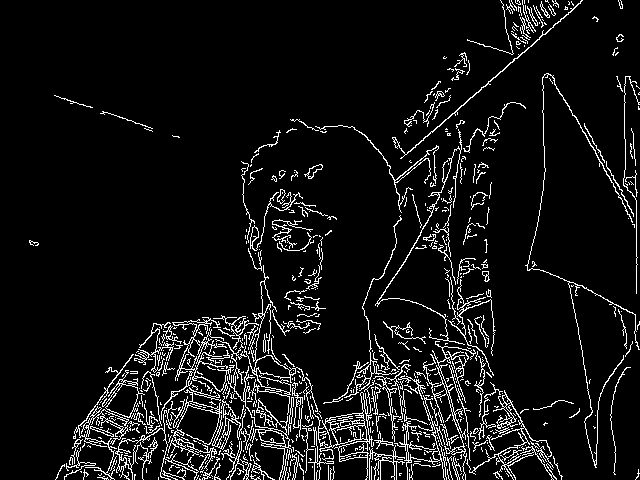


Frame processing complete. Re-run this cell to capture a new frame or change the filter.


In [13]:
# Key Note:
# it's crucial to understand that cv2.VideoCapture(0) for live webcam access
# will almost certainly not work in Google Colab.
# Colab's backend cannot directly access your local computer's camera.

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import PIL # Used implicitly by PIL.Image.open and then converting to numpy

# Constants for filters
PREVIEW  = 0  # Preview Mode
BLUR     = 1  # Blurring Filter
FEATURES = 2  # Corner Feature Detector
CANNY    = 3  # Canny Edge Detector

feature_params = dict(maxCorners=500, qualityLevel=0.2, minDistance=15, blockSize=9)

# --- JavaScript and Python bridge for Webcam Access ---
def video_frame(quality=0.8): # Function to capture a frame via JavaScript
  js = Javascript('''
    async function video_frame(quality) {
      const video = document.createElement('video');
      video.autoplay = true;
      video.muted = true;
      video.playsinline = true; // Added for iOS compatibility
      document.body.appendChild(video);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      document.body.removeChild(video);
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('video_frame({})'.format(quality)) # Execute JS and get data
  return data

def get_frame_from_webcam(): # Python wrapper to get and decode the frame
  data = video_frame()
  binary = b64decode(data.split(',')[1])
  # Decode bytes to OpenCV numpy array
  np_array = np.frombuffer(binary, np.uint8)
  frame = cv2.imdecode(np_array, cv2.IMREAD_COLOR)
  return frame

# --- Main Application Logic (using webcam frame) ---
print("Click 'Run anyway' and allow camera access in your browser if prompted.")
print("To change filters, modify 'current_filter' variable below and re-run this cell.")

current_filter = CANNY # <--- CHANGE THIS VALUE to BLUR, FEATURES, or CANNY to switch filter

frame = None
try:
    # Attempt to get a frame from the webcam
    frame = get_frame_from_webcam()
except Exception as e:
    print(f"Error getting frame from webcam: {e}")
    print("This usually means camera access was denied or there's an issue with the webcam.")

if frame is None:
    print("Failed to capture frame from webcam. Please ensure camera access is granted.")
else:
    # Resize image for better display if it's too large
    if frame.shape[0] > 720 or frame.shape[1] > 1280:
        scale_percent = 720 / frame.shape[0]
        width = int(frame.shape[1] * scale_percent)
        height = int(frame.shape[0] * scale_percent)
        dim = (width, height)
        frame = cv2.resize(frame, dim, interpolation = cv2.INTER_AREA)

    frame = cv2.flip(frame, 1) # Flip horizontally for mirror effect

    result = None
    filter_name = ""

    if current_filter == PREVIEW:
        result = frame
        filter_name = "Original"
    elif current_filter == CANNY:
        # Canny requires a grayscale image
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        result = cv2.Canny(gray_frame, 80, 150)
        filter_name = "Canny Edge"
    elif current_filter == BLUR:
        result = cv2.blur(frame, (13, 13))
        filter_name = "Blur"
    elif current_filter == FEATURES:
        result = frame.copy()
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners = cv2.goodFeaturesToTrack(frame_gray, **feature_params)
        if corners is not None:
            for x, y in np.float32(corners).reshape(-1, 2):
                cv2.circle(result, (int(x), int(y)), 5, (0, 255, 0), -1)
        else:
            print("No features found with current parameters.")
        filter_name = "Features"
    else:
        result = frame # Default to preview if filter is unknown
        filter_name = "Unknown Filter (Defaulting to Original)"

    # Add text to the image to show the current filter
    if result is not None:
        cv2.putText(result, f"Filter: {filter_name}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

        # Display the result
        cv2_imshow(result)
    else:
        print(f"Could not apply {filter_name} filter.")

print("\nFrame processing complete. Re-run this cell to capture a new frame or change the filter.")
# No need for source.release() or cv2.destroyAllWindows() as we are not using VideoCapture from cv2 directly

import cv2
import sys
import numpy

PREVIEW  = 0  # Preview Mode
BLUR     = 1  # Blurring Filter
FEATURES = 2  # Corner Feature Detector
CANNY    = 3  # Canny Edge Detector

feature_params = dict(maxCorners=500, qualityLevel=0.2, minDistance=15, blockSize=9)
s = 0
if len(sys.argv) > 1:
    s = sys.argv[1]

image_filter = PREVIEW
alive = True

win_name = "Camera Filters"
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
result = None

source = cv2.VideoCapture(s)

while alive:
    has_frame, frame = source.read()
    if not has_frame:
        break

    frame = cv2.flip(frame, 1)

    if image_filter == PREVIEW:
        result = frame
    elif image_filter == CANNY:
        result = cv2.Canny(frame, 80, 150)
    elif image_filter == BLUR:
        result = cv2.blur(frame, (13, 13))
    elif image_filter == FEATURES:
        result = frame
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners = cv2.goodFeaturesToTrack(frame_gray, **feature_params)
        if corners is not None:
            for x, y in numpy.float32(corners).reshape(-1, 2):
                cv2.circle(result, (int(x), int(y)), 10, (0, 255, 0), 1)

    cv2.imshow(win_name, result)

    key = cv2.waitKey(1)
    if key == ord("Q") or key == ord("q") or key == 27:
        alive = False
    elif key == ord("C") or key == ord("c"):
        image_filter = CANNY
    elif key == ord("B") or key == ord("b"):
        image_filter = BLUR
    elif key == ord("F") or key == ord("f"):
        image_filter = FEATURES
    elif key == ord("P") or key == ord("p"):
        image_filter = PREVIEW

source.release()
cv2.destroyWindow(win_name)